# 08 — Performance under Normal vs Extreme Conditions

How do the models hold up when the grid is calm versus when it's under stress?

**Important caveat — there is no weather data in this project.** The feature matrix has no
temperature/wind columns, and the models never see weather as an input. So we cannot literally
condition on a thermometer reading. Instead we use the **price-stress and seasonal signatures
that notebook 01 tied directly to extreme weather** — the Feb-2021 Winter Storm Uri spike, the
Jan-2024 polar vortex, and summer heat-wave spikes. Concretely:

- **Extreme conditions** = test hours whose realised LMP clears a *spike threshold*
  (train mean + 3·std — the same convention used in notebooks 01/02). These are the
  polar-vortex / heat-wave hours.
- **Normal conditions** = everything below the threshold.
- We also break results down **by season** (winter cold / summer heat / shoulder) and zoom in
  on the **January 2024 polar vortex** as the canonical extreme-weather event.

Same data, same models, and the same 2022→2023 train / 2024 test split as notebooks 03 and 07.

> Want true weather conditioning? The clean extension is to pull hourly temperature (e.g. via
> `meteostat`) for a Chicago/Illinois station and relabel hours by extreme cold/heat. Noted as
> follow-up; this notebook stays dependency-free.

In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Same 4-year feature matrix, feature set, and split as notebooks 03/07.
df = pd.read_csv('data/features/feature_matrix_v2.csv', parse_dates=['Time'], index_col='Time')

TARGET   = 'LMP'
FEATURES = [c for c in df.columns if c not in ['LMP', 'Energy', 'Congestion', 'Loss']]
X, y = df[FEATURES], df[TARGET]

train_start, split_date = '2022-01-01', '2024-01-01'
X_train = X[(X.index >= train_start) & (X.index < split_date)]
X_test  = X[X.index >= split_date]
y_train = y[(y.index >= train_start) & (y.index < split_date)]
y_test  = y[y.index >= split_date]

scaler         = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  ({len(X_train):,} rows)")
print(f"Test:  {X_test.index.min().date()} -> {X_test.index.max().date()}  ({len(X_test):,} rows)")

Train: 2022-01-01 -> 2023-12-31  (17,520 rows)
Test:  2024-01-01 -> 2024-12-31  (8,784 rows)


## Train the models, predict the 2024 test set

Identical model configs to notebook 07. We train once on 2022–2023, predict the full 2024 test
set, then *slice those predictions* into normal vs extreme buckets — so every comparison below is
on the exact same models.

In [3]:
# Linear + DNN use scaled features; tree models use raw. XGBoost is the saved champion.
lr  = LinearRegression().fit(X_train_scaled, y_train)
bag = BaggingRegressor(n_estimators=100, max_samples=0.8, max_features=0.8,
                       n_jobs=-1, random_state=42).fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=300, max_depth=16, min_samples_leaf=5,
                            max_features='sqrt', n_jobs=-1, random_state=42).fit(X_train, y_train)
dnn = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
                   alpha=1e-3, batch_size=256, learning_rate_init=1e-3, max_iter=300,
                   early_stopping=True, n_iter_no_change=15, validation_fraction=0.1,
                   random_state=42).fit(X_train_scaled, y_train)
xgb_model = xgb.XGBRegressor(); xgb_model.load_model('models/xgb_lmp_v1.json')

preds = {
    'Linear':        lr.predict(X_test_scaled),
    'Bagging':       bag.predict(X_test),
    'Random Forest': rf.predict(X_test),
    'DNN':           dnn.predict(X_test_scaled),
    'XGBoost':       xgb_model.predict(X_test),
}
P = pd.DataFrame(preds, index=y_test.index)
P['actual'] = y_test.values
print("Predictions ready for", list(preds), "on", len(P), "test hours")

Predictions ready for ['Linear', 'Bagging', 'Random Forest', 'DNN', 'XGBoost'] on 8784 test hours


## Define the conditions

The **spike threshold** is `train mean + 3·std`, computed on the 2022–2023 *training* prices, so
the cut point isn't tuned to the test set. Hours at/above it are the extreme (weather-driven)
events; everything else is normal.

In [4]:
thr      = y_train.mean() + 3 * y_train.std()
extreme  = y_test >= thr
normal   = ~extreme

print(f"Spike threshold (train mean + 3 std): ${thr:,.2f}/MWh")
print(f"Extreme hours: {extreme.sum():,}  ({extreme.mean()*100:.1f}% of 2024)")
print(f"Normal  hours: {normal.sum():,}  ({normal.mean()*100:.1f}% of 2024)")
print(f"\nExtreme-hour price range: ${y_test[extreme].min():.0f} -> ${y_test[extreme].max():.0f}/MWh")
print("Extreme hours by month:")
print(y_test[extreme].groupby(y_test[extreme].index.month).size().rename('hours').to_string())

Spike threshold (train mean + 3 std): $132.52/MWh
Extreme hours: 51  (0.6% of 2024)
Normal  hours: 8,733  (99.4% of 2024)

Extreme-hour price range: $133 -> $228/MWh
Extreme hours by month:
Time
1    38
7     5
8     8


## Normal vs Extreme — error per model

For each model we report MAE and RMSE separately on the normal and extreme buckets.

In [5]:
def seg_scores(mask, label):
    yt = y_test[mask]
    rows = []
    for name in preds:
        yp = P.loc[mask, name]
        rows.append({'Model': name, 'Segment': label, 'n': int(mask.sum()),
                     'MAE': mean_absolute_error(yt, yp),
                     'RMSE': np.sqrt(mean_squared_error(yt, yp))})
    return pd.DataFrame(rows)

cond = pd.concat([seg_scores(normal, 'Normal'),
                  seg_scores(extreme, 'Extreme')], ignore_index=True)

# Side-by-side MAE view (normal vs extreme) with the degradation factor
mae_wide = cond.pivot(index='Model', columns='Segment', values='MAE')
mae_wide['x_factor'] = (mae_wide['Extreme'] / mae_wide['Normal']).round(1)
mae_wide = mae_wide.round(2).sort_values('Extreme')

print("MAE by model and condition ($/MWh):")
print(mae_wide.to_string())
print("\nFull table (MAE + RMSE):")
print(cond.round(2).to_string(index=False))
mae_wide

MAE by model and condition ($/MWh):
Segment        Extreme  Normal  x_factor
Model                                   
Linear           65.31    5.65      11.6
DNN              69.38    7.06       9.8
XGBoost          78.92    5.45      14.5
Bagging          79.97    5.53      14.5
Random Forest    82.96    5.61      14.8

Full table (MAE + RMSE):
        Model Segment    n   MAE  RMSE
       Linear  Normal 8733  5.65  8.40
      Bagging  Normal 8733  5.53  8.51
Random Forest  Normal 8733  5.61  8.53
          DNN  Normal 8733  7.06 10.43
      XGBoost  Normal 8733  5.45  8.48
       Linear Extreme   51 65.31 69.39
      Bagging Extreme   51 79.97 84.80
Random Forest Extreme   51 82.96 87.26
          DNN Extreme   51 69.38 75.35
      XGBoost Extreme   51 78.92 83.73


Segment,Extreme,Normal,x_factor
Model,,,
Linear,65.31,5.65,11.6
DNN,69.38,7.06,9.8
XGBoost,78.92,5.45,14.5
Bagging,79.97,5.53,14.5
Random Forest,82.96,5.61,14.8


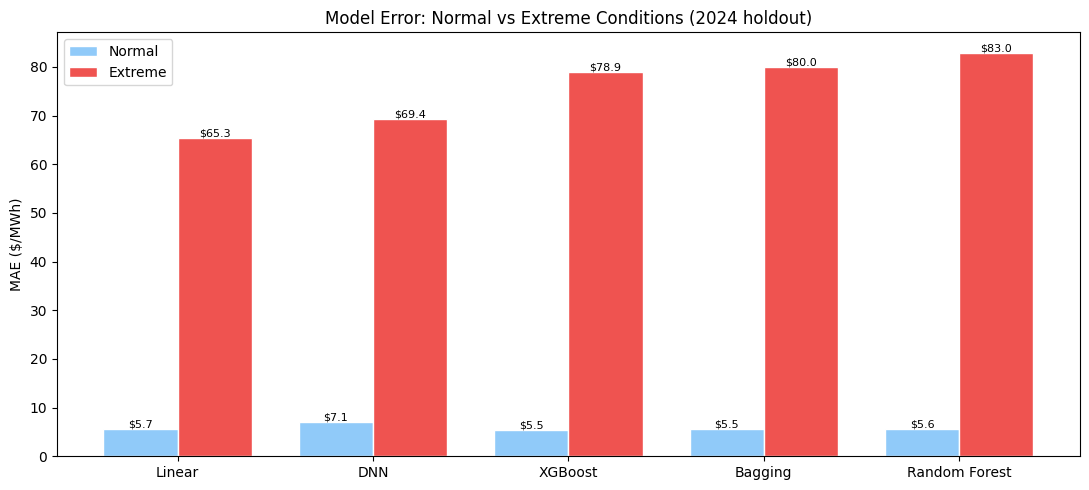

In [6]:
# --- Grouped bar: Normal vs Extreme MAE per model ---
order  = mae_wide.index.tolist()
xpos   = np.arange(len(order))
w      = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(xpos - w/2, mae_wide['Normal'],  w, label='Normal',  color='#90CAF9', edgecolor='white')
ax.bar(xpos + w/2, mae_wide['Extreme'], w, label='Extreme', color='#EF5350', edgecolor='white')
ax.set_xticks(xpos); ax.set_xticklabels(order)
ax.set_ylabel('MAE ($/MWh)')
ax.set_title('Model Error: Normal vs Extreme Conditions (2024 holdout)')
ax.legend()
for i, m in enumerate(order):
    ax.text(i - w/2, mae_wide['Normal'][m]  + 0.3, f"${mae_wide['Normal'][m]:.1f}",  ha='center', fontsize=8)
    ax.text(i + w/2, mae_wide['Extreme'][m] + 0.3, f"${mae_wide['Extreme'][m]:.1f}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('results/conditions_comparison.png', dpi=150)
plt.show()

## Robustness — error across price-stress bands

A single threshold is one cut. This bins the test hours by realised price level and shows MAE
climbing as conditions intensify — a threshold-free view of the same story.

In [7]:
bins   = [0, 50, 100, 150, np.inf]
labels = ['<$50', '$50-100', '$100-150', '>$150']
band   = pd.cut(y_test, bins=bins, labels=labels, right=False)

band_mae = pd.DataFrame({
    name: y_test.groupby(band).apply(
        lambda idx, n=name: mean_absolute_error(y_test[idx.index], P.loc[idx.index, n])
    ) for name in preds
})
band_mae.insert(0, 'n_hours', y_test.groupby(band).size())
print("MAE ($/MWh) by realised-price band:")
print(band_mae.round(2).to_string())
band_mae.round(2)

MAE ($/MWh) by realised-price band:
          n_hours  Linear  Bagging  Random Forest    DNN  XGBoost
LMP                                                              
<$50         8288    4.92     4.81           4.88   6.28     4.70
$50-100       411   17.03    16.80          16.86  19.82    17.29
$100-150       48   49.24    46.83          48.77  44.62    48.00
>$150          36   69.99    91.73          95.13  77.35    90.06


,n_hours,Linear,Bagging,Random Forest,DNN,XGBoost
LMP,,,,,,
<$50,8288,4.92,4.81,4.88,6.28,4.70
$50-100,411,17.03,16.80,16.86,19.82,17.29
$100-150,48,49.24,46.83,48.77,44.62,48.00
>$150,36,69.99,91.73,95.13,77.35,90.06


## Seasonal lens — winter cold vs summer heat vs shoulder

Extreme weather is seasonal: cold snaps in winter, heat waves in summer. Mild shoulder months
(spring/autumn) are the easy case.

In [8]:
m       = y_test.index.month
season  = pd.Series(np.select([m.isin([12, 1, 2]), m.isin([6, 7, 8])],
                              ['Winter (cold)', 'Summer (heat)'], default='Shoulder'),
                    index=y_test.index)

seas_mae = pd.DataFrame({
    name: y_test.groupby(season).apply(
        lambda idx, n=name: mean_absolute_error(y_test[idx.index], P.loc[idx.index, n])
    ) for name in preds
})
seas_mae.insert(0, 'n_hours', y_test.groupby(season).size())
seas_mae = seas_mae.reindex(['Winter (cold)', 'Shoulder', 'Summer (heat)'])
print("MAE ($/MWh) by season:")
print(seas_mae.round(2).to_string())
seas_mae.round(2)

MAE ($/MWh) by season:
               n_hours  Linear  Bagging  Random Forest    DNN  XGBoost
Winter (cold)     2184    8.19     8.11           8.31  10.04     8.18
Shoulder          4392    5.02     5.01           5.06   6.24     4.77
Summer (heat)     2208    5.77     5.73           5.81   7.16     5.82


,n_hours,Linear,Bagging,Random Forest,DNN,XGBoost
Winter (cold),2184,8.19,8.11,8.31,10.04,8.18
Shoulder,4392,5.02,5.01,5.06,6.24,4.77
Summer (heat),2208,5.77,5.73,5.81,7.16,5.82


## Zoom: the January 2024 polar vortex

The clearest extreme-weather event in the test year. Watch every model under-predict the spike —
the structural limitation of pattern-based forecasting when an unprecedented cold snap hits.

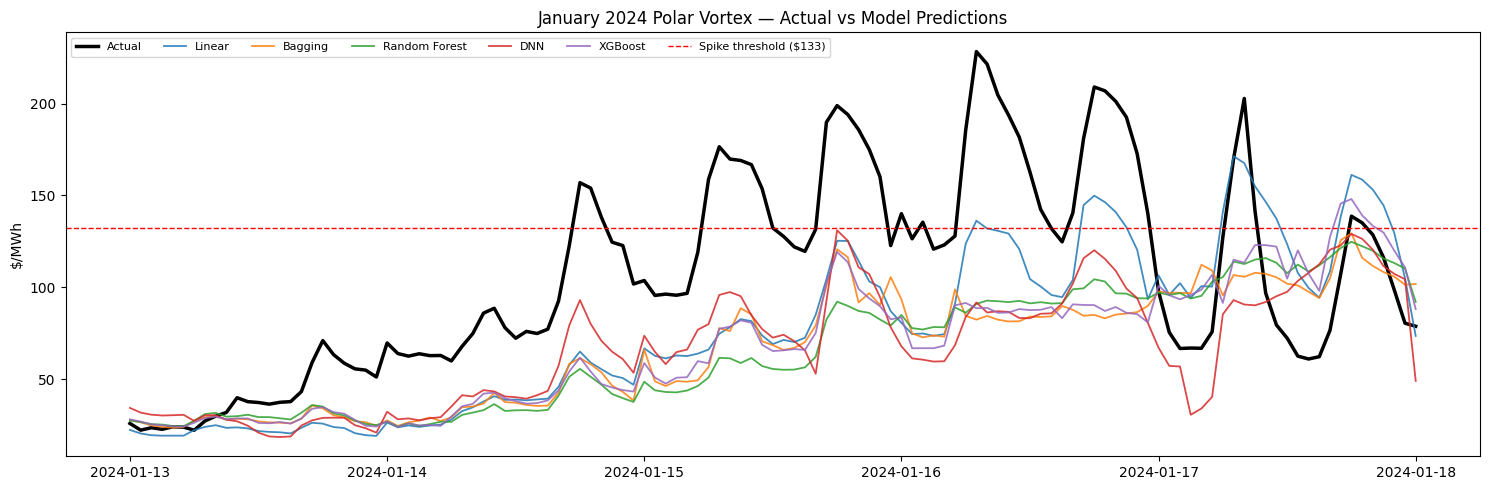

Peak actual: $228/MWh at 2024-01-16 07:00:00-05:00
Model predictions at that hour:
Linear           136.2
Bagging           82.4
Random Forest     91.0
DNN               91.8
XGBoost           88.7


In [9]:
win = (P.index >= '2024-01-13') & (P.index <= '2024-01-18')
sub = P[win]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(sub.index, sub['actual'], label='Actual', color='black', linewidth=2.5)
for name in preds:
    ax.plot(sub.index, sub[name], linewidth=1.3, alpha=0.85, label=name)
ax.axhline(thr, color='red', linestyle='--', linewidth=1, label=f'Spike threshold (${thr:.0f})')
ax.set_title('January 2024 Polar Vortex — Actual vs Model Predictions')
ax.set_ylabel('$/MWh')
ax.legend(ncol=7, fontsize=8)
plt.tight_layout()
plt.savefig('results/conditions_polar_vortex.png', dpi=150)
plt.show()

peak = sub['actual'].idxmax()
print(f"Peak actual: ${sub['actual'].max():.0f}/MWh at {peak}")
print("Model predictions at that hour:")
print(sub.loc[peak, list(preds)].round(1).to_string())

In [10]:
# Persist the condition comparison
cond.round(3).to_csv('results/conditions_comparison.csv', index=False)
print('Saved results/conditions_comparison.csv')

Saved results/conditions_comparison.csv


## Takeaways

**Extreme is rare but brutal.** Only **51 of 8,784** test hours (0.6%) clear the $132.52 spike threshold — almost all in **January** (38 hours, the polar vortex), with a handful in July/August (heat). But every model's error explodes **~10–15×** on those hours:

| Model | Normal MAE | Extreme MAE | ×factor |
|---|---|---|---|
| Linear | $5.65 | **$65.31** | 11.6× |
| DNN | $7.06 | $69.38 | 9.8× |
| XGBoost | **$5.45** | $78.92 | 14.5× |
| Bagging | $5.53 | $79.97 | 14.5× |
| Random Forest | $5.61 | $82.96 | 14.8× |

**1. The leaderboard flips.** XGBoost is the **best in normal conditions** ($5.45) but the **3rd-worst in extreme** ($78.92). In the spike hours the order reverses: **Linear ($65) and the DNN ($69) degrade least**, while the tree ensembles (XGBoost, Bagging, RF) are the worst.

**2. Why — trees can't extrapolate.** At the $228 polar-vortex peak (Jan 16, 7am), the tree models cap out around **$82–91** because a tree's prediction can never exceed the values seen in training — it physically cannot output a price beyond its leaf averages. **Linear regression extrapolates** and reached **$136**, much closer (still short, but it's not boxed in). This is the textbook trees-vs-linear extrapolation trade-off, shown live on grid prices.

**3. The degradation is monotonic** (price-band table): MAE climbs ~$5 → $17 → $48 → $70+ as realised price rises, and the tree-vs-linear gap only opens up in the top `>$150` band, where trees hit **$90–95** vs Linear's **$70**.

**4. Seasonally, winter is the hard season** (MAE ~$8.2 vs ~$5 in shoulder months) — that's the cold-snap signature. Summer heat is milder here (~$5.8). The DNN is consistently the weakest *within every* season.

**Implication.** A champion chosen on overall/normal-condition accuracy (XGBoost) is **not** the model you want for tail-risk / spike exposure. For an operator who cares about extreme events, sensible next steps are: add real **weather features** (temperature, HDD/CDD) so the model has a *reason* to predict a spike; train a dedicated **spike classifier** or **quantile model**; or **ensemble** a tree (great in normal) with a linear/extrapolating model (better in the tail).

**Artifacts written:** `results/conditions_comparison.csv`, `results/conditions_comparison.png`, `results/conditions_polar_vortex.png`.